## **Questions**

**Question 1:** What would be the total base stat for an average Pokémon?


**Question 2**: Do legendary Pokémon have statistically higher mean total base stats than all other Pokémon?


**Question 3:** Are the sums of special attack and special defense related to the sums of regular attack and regular defense?




<br>

<br>

## **Data**


- One of the columns analysis was conducted on was the ‘Total’ column. A higher total stat typically means a stronger Pokémon.

- Some other columns analyzed include the ‘Attack’ and ‘Defense’ columns, and the ‘Sp. Attack’ and ‘Sp. Defense’ columns. Pokémon in the Pokémon games have normal attacks as well as special attacks. The stats in the columns above measure a Pokémon's ability to execute and defend against each respective attack.

- Another column observed was the ‘Legendary’ column. This column contains boolean values that tell us if a Pokémon is legendary or not.

<br>

<br>

<br>


## **Methods**
Some methods used  to conduct statistical analysis include data visualization, central tendency measures, correlation, and a z-test (hypothesis test).



<br>

<br>

# **Results**


In [ ]:
import pandas as pd

data_url = 'https://raw.githubusercontent.com/csbfx/advpy122-data/master/Pokemon.csv'
poke_df = pd.read_csv(data_url)
poke_df

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,719,Diancie,Rock,Fairy,600,50,100,150,100,150,50,6,True
796,719,DiancieMega Diancie,Rock,Fairy,700,50,160,110,160,110,110,6,True
797,720,HoopaHoopa Confined,Psychic,Ghost,600,80,110,60,150,130,70,6,True
798,720,HoopaHoopa Unbound,Psychic,Dark,680,80,160,60,170,130,80,6,True


<br>

<br>

#### **Data Visualization A: Histogram**

Text(0.5, 1.0, "Distribution of 'Total'")

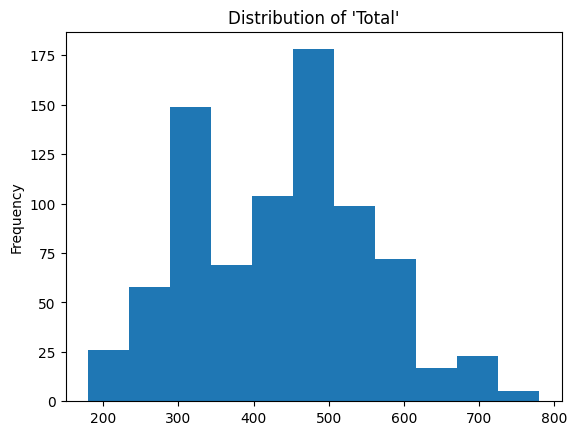

In [ ]:
poke_df["Total"].plot.hist(bins=11).set_title("Distribution of 'Total'")

This histogram tells us that the distribution of the data ‘Total’ is not normally distributed.


<br>

<br>

<br>

### **Central Tendency**

**Question 1:** What would be the total base stat for an average Pokémon?

The total base stat for an average Pokémon would be **450**, which was obtained by finding the median of the dataset ‘Total.’

In [ ]:
import numpy as np
# find the number of outliers in total
total_sorted = poke_df['Total'].sort_values().to_frame()
total_sorted.columns = ['Total']

q1 = np.percentile(total_sorted, 25)
q3 = np.percentile(total_sorted, 75)
iqr = q3 - q1

new_total = total_sorted.loc[(total_sorted['Total'] >= (q1 - 1.5*iqr)) & (total_sorted['Total'] <= (q3 + 1.5*iqr))]
print(f'Number of outliers is {len(poke_df) - len(new_total)}')

# median
pokeMedian = poke_df['Total'].median()
print(f'Median: {round(pokeMedian,2)}')





Number of outliers is 0
Median: 450.0
Population Standard Deviation: 119.89


<br>

<br>



### **Z-Test**

**Question 2:** Do legendary pokemon have significantly higher mean total base stats than all other pokemon?

H0: Legendary pokemon do not have a statistically higher mean total base stat than all other pokemon

HA: Legendary pokemon do have a statistically higher mean total base stat than all other pokemon.

The test tells us that our z-score is 14.19, and since 14.19 > 1.65, the z-score is greater than the z-critical value. The null has been rejected in favor of the alternative. **Thus, legendary Pokémon do have a statistically higher mean total base stat than all other Pokémon.**


In [ ]:
###Calculating population standard deviation (cannot use .std() as that only works for sample standard deviation)
# Calculate the squared deviation
pokeMean = poke_df['Total'].mean()
poke_df['squared_deviation'] = (poke_df['Total']-pokeMean)**2

# Calculate the variance
variance = poke_df['squared_deviation'].mean() #applicable because we are finding population standard deviation

# Calculate the standard deviation
import numpy as np
pokeStd = np.sqrt(variance)
print(f"Population Standard Deviation: {round(pokeStd,2)}")

# Creates one dataframe of just legendaries and one of all other pokemon
legendary = poke_df.loc[poke_df['Legendary'] == True]
all_others= poke_df.loc[poke_df['Legendary'] == False]


# finds the mean and length of both samples
legendary_mean = legendary['Total'].mean()
legendary_n = len(legendary)


all_others_mean = all_others['Total'].mean()
all_others_n = len(all_others)


# z score calculation
z = (legendary_mean - all_others_mean)/np.sqrt((pokeStd**2 / legendary_n) + (pokeStd ** 2 / all_others_n)) # legendary is the minuend by the nature of the question, denominator is pooled standard error because we are using z-test to compare two samples.
print(f"Z-Score: {round(z,2)}")

z_crit = 1.65 # at one tail, alpha = 0.05

if (z > z_crit):
  print("Null rejected.")
else:
  print("Null accepted.")


Z-Score: 14.19
Null rejected.


In [ ]:
poke_df["Sp. Sum"] = poke_df["Sp. Atk"] + poke_df["Sp. Def"]
poke_df["Reg Sum"] = poke_df["Attack"] + poke_df["Defense"]
poke_df

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,squared_deviation,Sp. Sum,Reg Sum
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False,13712.995506,130,98
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False,906.160506,160,125
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False,8081.560506,200,165
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False,36061.060506,242,223
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False,15901.840506,110,95
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,719,Diancie,Rock,Fairy,600,50,100,150,100,150,50,6,True,27191.185506,250,250
796,719,DiancieMega Diancie,Rock,Fairy,700,50,160,110,160,110,110,6,True,70170.685506,270,270
797,720,HoopaHoopa Confined,Psychic,Ghost,600,80,110,60,150,130,70,6,True,27191.185506,280,170
798,720,HoopaHoopa Unbound,Psychic,Dark,680,80,160,60,170,130,80,6,True,59974.785506,300,220


<br>

<br>

<br>

#### **Data Visualization B1: Histogram**

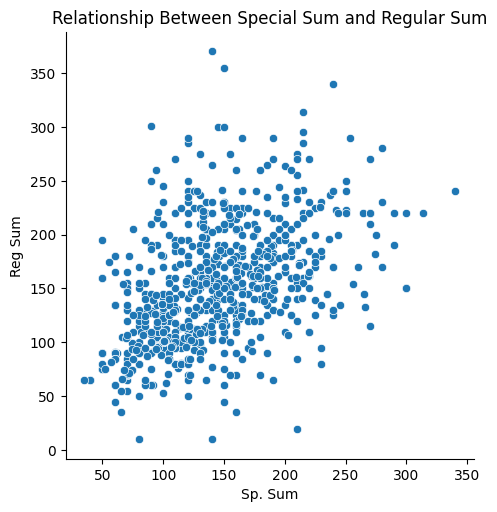

In [ ]:
import seaborn as sns
sns.relplot(data = poke_df, x = "Sp. Sum", y = "Reg Sum").set(title = "Relationship Between Special Sum and Regular Sum")

Outliers make it difficult to observe the overall relationship. We can use the IQR to remove outliers.

<br>

<br>


#### **Data Visualization B2: Scatterplot (without outliers)**

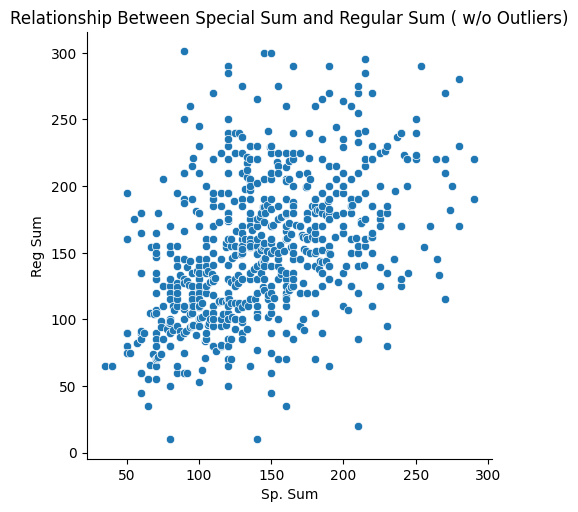

In [ ]:

sp_sorted = poke_df['Sp. Sum'].sort_values().to_frame()
sp_sorted.columns = ['Sp. Sum']

reg_sorted = poke_df['Reg Sum'].sort_values().to_frame()
reg_sorted.columns = ['Reg Sum']

sq1 = np.percentile(sp_sorted, 25)
sq3 = np.percentile(sp_sorted, 75)
siqr = sq3 - sq1

rq1 = np.percentile(reg_sorted, 25)
rq3 = np.percentile(reg_sorted,75)
riqr = rq3 - rq1

new_sp = sp_sorted.loc[(sp_sorted['Sp. Sum'] >= (sq1 - 1.5*siqr)) & (sp_sorted['Sp. Sum'] <= (sq3+1.5*siqr))]


new_reg = reg_sorted.loc[(reg_sorted['Reg Sum'] >= (rq1 - 1.5*riqr)) & (reg_sorted['Reg Sum'] <= (rq3+1.5*riqr))]


sums_merged = pd.concat([new_sp, new_reg], axis=1)

sns.relplot(data = sums_merged, x = 'Sp. Sum', y = 'Reg Sum').set(title = "Relationship Between Special Sum and Regular Sum ( w/o Outliers)")



Now that we have a clearer look, we can assume a line of best fit that shows a positive linear relationship. This means if 'Reg Sum' increases, 'Sp. Sum' also increases. We can also observe that both 'Sp. Sum' and 'Reg Sum' provide a wide range of potential values. This justifies using the correlation analysis.

<br>

<br>



### **Correlation**

**Question 3:** Are the sums of special attack and special defense related to the sums of regular attack and regular defense?

H0: There is no relationship between the sums of special attack and special defense and the sums of regular attack and regular defense.

HA: There is a relationship between the sums of special attack and special defense and the sums of regular attack and regular defense.

Upon obtaining the Pearson correlation coefficient of about 0.47, we can understand that there is a fairly strong relationship between the two variables. The obtained p-value being much less than the alpha value of 0.05 tells us that the null hypothesis is rejected in favor of the alternative. **Thus, there is a relationship between the sums of special attack and special defense and the sums of regular attack and regular defense.**

In [ ]:
from scipy import stats

pearson_corr, p_value = stats.pearsonr(poke_df["Sp. Sum"], poke_df["Reg Sum"])
print(pearson_corr)
print(p_value)


0.468658785173672
6.360749248876667e-45


The Pearson correlation coefficient found shows a fairly high level of correlation. Since the p-value found is much smaller than the alpha level 0.05, we reject the null in favor of the alternative.